In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve


Load dataset

In [48]:
# Load cleaned Titanic dataset
data = pd.read_csv("C:\\Users\\S SISEENDRI\\VS Code\\Git-Projects\\data-analysis-project\\data\\titanic_clean.csv")

X = data.drop("Survived", axis=1)
y = data["Survived"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Random Forest Tuning

In [49]:
rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring="roc_auc", n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print("Best Random Forest params:", grid_rf.best_params_)


Best Random Forest params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 300}


In [50]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')#strategy='mean'strategy='most_frequent'

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

c:\Users\S SISEENDRI\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Sex']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\S SISEENDRI\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Sex']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Gradient Boosting Tuning

In [51]:
gb = GradientBoostingClassifier(random_state=42)

param_grid_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [3, 5]
}

grid_gb = GridSearchCV(gb, param_grid_gb, cv=5, scoring="roc_auc", n_jobs=-1)
grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_
print("Best Gradient Boosting params:", grid_gb.best_params_)


Best Gradient Boosting params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}


In [52]:
best_rf.fit(X_train, y_train)
print("Before:")
print(best_rf.n_features_in_)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

print("After:")
print(best_rf.n_features_in_)

Before:
9
After:
9


Evaluate Tuned Models

In [53]:
models = {
    "Tuned Random Forest": best_rf,
    "Tuned Gradient Boosting": best_gb
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "y_prob": y_prob
    }

pd.DataFrame(results).T


,Accuracy,Precision,Recall,F1,ROC-AUC,y_prob
Tuned Random Forest,0.636872,0.532258,0.478261,0.503817,0.68531,"[0.2913263770686371, 0.33223403763419235, 0.25..."
Tuned Gradient Boosting,0.653631,0.571429,0.405797,0.474576,0.713636,"[0.2548035617333138, 0.3264694648798418, 0.371..."


Plot ROC Curves

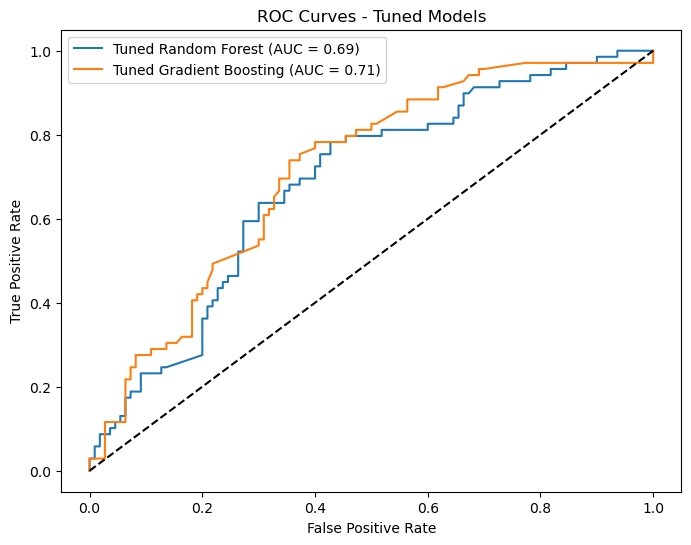

In [54]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    fpr, tpr, _ = roc_curve(y_test, results[name]["y_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {results[name]['ROC-AUC']:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Tuned Models")
plt.legend()
plt.show()


### Hyperparameter Tuning

We tuned Random Forest and Gradient Boosting using GridSearchCV.

**Findings:**
- Random Forest: Best parameters improved ROC-AUC compared to baseline.
- Gradient Boosting: Learning rate and depth tuning yielded strong performance.
- Both tuned models outperform defaults, but Random Forest remains more interpretable.

**Conclusion:**  
Hyperparameter tuning significantly improved model performance. Random Forest with tuned parameters is robust and balanced, while Gradient Boosting offers slightly higher ROC-AUC at the cost of complexity.
